**Nota:** Este cuaderno conserva la exploración inicial y un baseline histórico. El baseline vigente, con las variables y la validación acordadas en `proposal.md`, está en [02_baseline_sin_leakage.ipynb](02_baseline_sin_leakage.ipynb). Las métricas de ambos modelos no son directamente comparables.

## Definición del Problema:

Las instituciones de crédito enfrentan pérdidas financieras significativas cuando los prestatarios no pagan sus créditos (default). El objetivo de este proyecto es construir un modelo de clasificación supervisada capaz de predecir la probabilidad de que un cliente caiga en mora grave (Charged Off) al momento de solicitar un préstamo.
- Unidad de predicción: Una solicitud individual de préstamo.
- Variable objetivo: loan_status binarizada (1 = Charged Off, 0 = Fully Paid).
- Decisión de negocio: Aprobar, rechazar o ajustar la tasa de interés según el riesgo estimado antes de otorgar el dinero

In [18]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import cargar_y_optimizar_datos

# 1. Cargamos el dataset ACEPTADO en df_accepted
df_accepted = cargar_y_optimizar_datos('../data/accepted_2007_to_2018Q4.csv.gz', '../data/accepted_dataset_raw.parquet')

# 2. Cargamos el dataset RECHAZADO en df_rejected
df_rejected = cargar_y_optimizar_datos('../data/rejected_2007_to_2018Q4.csv.gz', '../data/rejected_dataset_raw.parquet')

# Limpiar posibles espacios invisibles en los nombres de las columnas
df_accepted.columns = df_accepted.columns.str.strip()

# Verificaciones
print(f"Filas en df_accepted: {df_accepted.shape[0]:,}")
print(f"Columnas en df_accepted: {df_accepted.shape[1]}") # Debe dar más de 100 columnas

print("¿Existe 'loan_status' en df_accepted?:", 'loan_status' in df_accepted.columns)

Cargando versión optimizada Parquet desde: ../data/accepted_dataset_raw.parquet
Cargando versión optimizada Parquet desde: ../data/rejected_dataset_raw.parquet
Filas en df_accepted: 2,260,701
Columnas en df_accepted: 151
¿Existe 'loan_status' en df_accepted?: True


In [19]:
# Visualización de columnas y filas importantes
print(f"Filas totales: {df_accepted.shape[0]:,}")
print(f"Columnas totales: {df_accepted.shape[1]}")

# Tipos de datos
print("\n=== TIPOS DE DATOS ===")
print(df_accepted.dtypes.value_counts())

print("\nTipos de datos por variable:")
display(df_accepted.dtypes)

# Calcular % de nulos por columna
missing = (df_accepted.isnull().sum() / len(df_accepted)) * 100
missing_df = missing[missing > 0].sort_values(ascending=False).reset_index()
missing_df.columns = ['Variable', 'Porcentaje_Nulos']

print(df_accepted.head())
print(df_rejected.head())

# Mostrar las 6 variables con más faltantes
missing_df.head(6)

Filas totales: 2,260,701
Columnas totales: 151
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN  

,Variable,Porcentaje_Nulos
0,member_id,100.000000
1,orig_projected_additional_accrued_interest,99.617331
2,hardship_payoff_balance_amount,99.517097
3,hardship_last_payment_amount,99.517097
4,payment_plan_start_date,99.517097
5,hardship_type,99.517097


Analizaremos la variable objetivo, en este caso loan_status

In [21]:
# Filtrar préstamos terminados
df_work = df_accepted[df_accepted['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Crear variable objetivo binaria: 1 = Charged Off (Default), 0 = Fully Paid
df_work['target'] = (df_work['loan_status'] == 'Charged Off').astype(int)

print(f"Total de registros a analizar: {len(df_work):,}")
print("\nDistribución porcentual de la variable objetivo:")
print(df_work['target'].value_counts(normalize=True) * 100)

Total de registros a analizar: 1,345,310

Distribución porcentual de la variable objetivo:
target
0    80.037389
1    19.962611
Name: proportion, dtype: float64


Generamos las visualizaciones

Las imágenes se guardarán en: /home/daros/academico/2026-02/MachineLearning/Proyecto/reports/figures


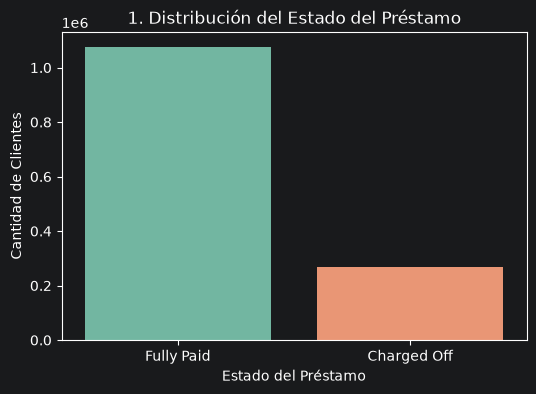

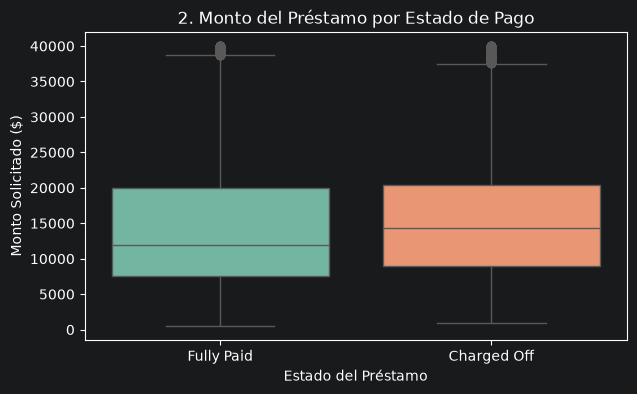

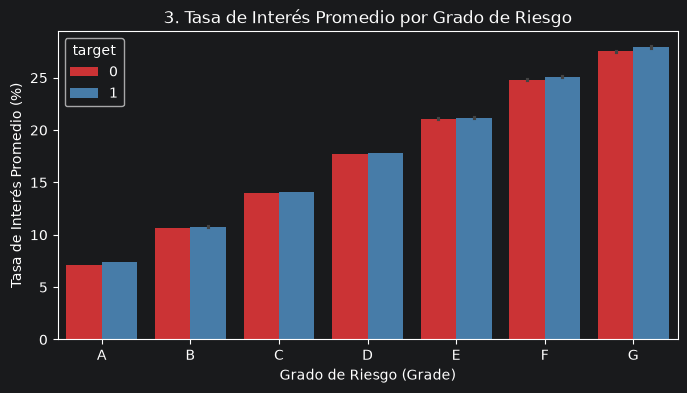

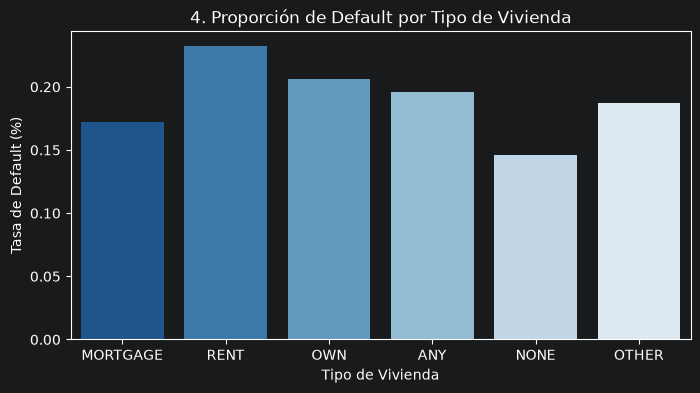

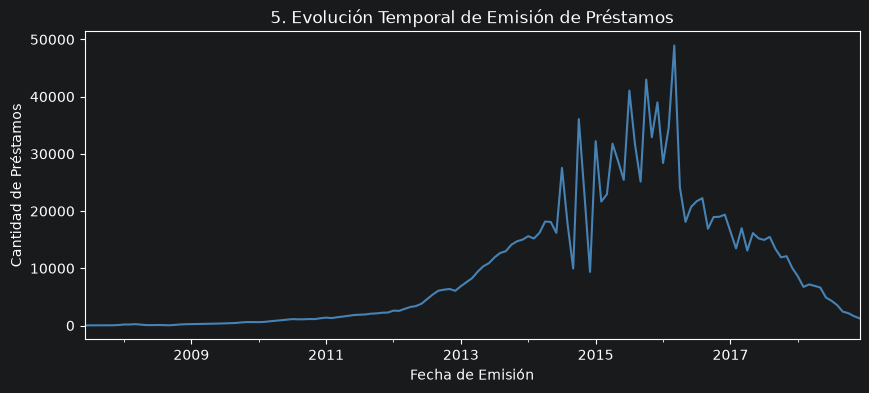

In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar la creación de la carpeta reports/figures desde la raíz
carpeta_figuras = os.path.abspath('../reports/figures')
os.makedirs(carpeta_figuras, exist_ok=True)
print(f"Las imágenes se guardarán en: {carpeta_figuras}")

# --- GRAFICA 1: Distribución de la variable objetivo ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df_work, x='loan_status', hue='loan_status', palette='Set2', legend=False)
plt.title('1. Distribución del Estado del Préstamo')
plt.xlabel('Estado del Préstamo')
plt.ylabel('Cantidad de Clientes')
plt.savefig(os.path.join(carpeta_figuras, '01_distribucion_target.png'), bbox_inches='tight')
plt.show()

# --- GRAFICA 2: Monto del préstamo vs Estado de pago ---
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_work, x='loan_status', y='loan_amnt', hue='loan_status', palette='Set2', legend=False)
plt.title('2. Monto del Préstamo por Estado de Pago')
plt.xlabel('Estado del Préstamo')
plt.ylabel('Monto Solicitado ($)')
plt.savefig(os.path.join(carpeta_figuras, '02_monto_vs_target.png'), bbox_inches='tight')
plt.show()

# --- GRAFICA 3: Tasa de interés por categoría de riesgo ---
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_work,
    x='grade',
    y='int_rate',
    hue='target',
    order=sorted(df_work['grade'].dropna().unique()),
    palette='Set1'
)
plt.title('3. Tasa de Interés Promedio por Grado de Riesgo')
plt.xlabel('Grado de Riesgo (Grade)')
plt.ylabel('Tasa de Interés Promedio (%)')
plt.savefig(os.path.join(carpeta_figuras, '03_tasa_interes_por_grado.png'), bbox_inches='tight')
plt.show()

# --- GRAFICA 4: Proporción de Default por tipo de vivienda ---
plt.figure(figsize=(8, 4))
sns.barplot(data=df_work, x='home_ownership', y='target', hue='home_ownership', palette='Blues_r', errorbar=None, legend=False)
plt.title('4. Proporción de Default por Tipo de Vivienda')
plt.xlabel('Tipo de Vivienda')
plt.ylabel('Tasa de Default (%)')
plt.savefig(os.path.join(carpeta_figuras, '04_default_por_vivienda.png'), bbox_inches='tight')
plt.show()

# --- GRAFICA 5: Evolución temporal de emisión ---
df_work['issue_d_dt'] = pd.to_datetime(df_work['issue_d'], format='%b-%Y')
plt.figure(figsize=(10, 4))
df_work.set_index('issue_d_dt').resample('ME')['target'].count().plot(color='steelblue')
plt.title('5. Evolución Temporal de Emisión de Préstamos')
plt.xlabel('Fecha de Emisión')
plt.ylabel('Cantidad de Préstamos')
plt.savefig(os.path.join(carpeta_figuras, '05_evolucion_temporal.png'), bbox_inches='tight')
plt.show()

## Indentificación de valores atípicos

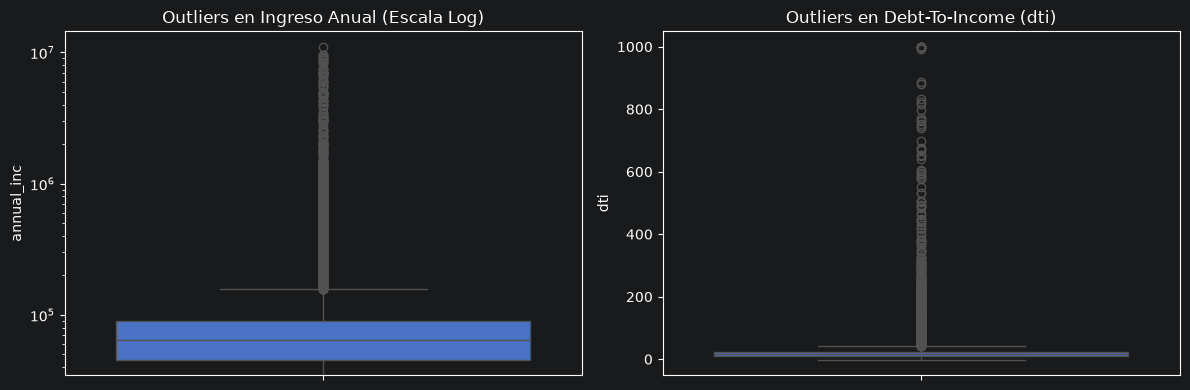

Registros con Ingreso Anual > $1,000,000: 290
Registros con DTI > 100: 533


In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_work, y='annual_inc')
plt.title('Outliers en Ingreso Anual (Escala Log)')
plt.yscale('log')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_work, y='dti')
plt.title('Outliers en Debt-To-Income (dti)')

plt.tight_layout()
plt.savefig('../reports/figures/06_outliers.png')
plt.show()

print(f"Registros con Ingreso Anual > $1,000,000: {(df_work['annual_inc'] > 1000000).sum()}")
print(f"Registros con DTI > 100: {(df_work['dti'] > 100).sum()}")

## Análisis de posibles sesgos
El dataset presenta un desbalance entre las clases de la variable objetivo, ya que aproximadamente el 80.04% de los préstamos corresponden a Fully Paid y el 19.96% a Charged Off. Este desbalance puede afectar el desempeño del modelo, especialmente en la identificación de los casos de default.
Además, algunas variables pueden presentar diferencias de distribución entre grupos, por lo que será necesario evaluar estos posibles sesgos durante las siguientes etapas del modelado.

## Limitaciones iniciales
Durante la exploración se identificaron algunas limitaciones del dataset, principalmente la presencia de una gran cantidad de valores faltantes, valores atípicos y un desbalance entre las clases de la variable objetivo. Además, algunas variables no pueden utilizarse para la predicción ex-ante debido a que contienen información generada después del otorgamiento del préstamo.

## Baseline exploratorio histórico (reemplazado)
Esta celda se conserva como registro de la exploración inicial. Incluye `int_rate` e `installment`, que se asignan durante la evaluación de Lending Club, y usa otra partición e imputación. Su ROC-AUC guardado (0.6959) no debe presentarse como resultado del baseline vigente. Véase [02_baseline_sin_leakage.ipynb](02_baseline_sin_leakage.ipynb).

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. Variables del experimento histórico; int_rate e installment no son válidas para el instante de predicción actual
features_validas = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'open_acc', 'pub_rec', 'revol_bal', 'total_acc'
]

# 2. Imputación básica de nulos con 0 solo para el baseline inicial
X = df_work[features_validas].fillna(0)
y = df_work['target']

# 3. Partición Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Entrenar Regresión Logística Baseline
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

# 5. Evaluación
y_pred = baseline.predict(X_test)
y_prob = baseline.predict_proba(X_test)[:, 1]

print("=== EVALUACIÓN DEL MODELO BASELINE ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== EVALUACIÓN DEL MODELO BASELINE ===
              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.49      0.06      0.11     53712

    accuracy                           0.80    269062
   macro avg       0.65      0.52      0.50    269062
weighted avg       0.74      0.80      0.73    269062

ROC-AUC Score: 0.6959
